In [1]:
import sys
import torch
from torch import nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, TensorDataset, ConcatDataset, Subset
from torchvision.utils import make_grid
import torch.nn.functional as F


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import random


import models as models
import train_helper as train_helper
import utils as utils
import data_helper as data_helper

vae_path = "/home/benjiy/repo/Verified-Synthetic-Data/MNIST"
sys.path.append(vae_path)

In [2]:
# Set up device and seed
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
base_seed = 0
torch.manual_seed(base_seed)
torch.cuda.manual_seed_all(base_seed)
np.random.seed(base_seed)
random.seed(base_seed)

model_saved_path = os.path.join(os.getcwd(),"model_saved")
data_saved_path = os.path.join(os.getcwd(),"data_saved")
results_saved_path = os.path.join(os.getcwd(),"results_saved")




## Prepare data ##


In [3]:


full_dataset = datasets.MNIST(root="./data", train=True, download=True, transform=transforms.ToTensor())

test_dataset = datasets.MNIST(root="./data", train=False, download=True,transform=transforms.ToTensor())
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)
full_digit_indices = utils.create_balanced_subset_indices(full_dataset,seed=base_seed)

#train_dataset_5000 = Subset(full_dataset, range(5000))


## Reproduce synthetic data retraining improving testing error

In [4]:
import shutil
init_size = 5000

all_models = []
test_results = {"val_loss":[], "val_recon":[], "val_kl":[], "model_name":[]}
init_subset = utils.get_balanced_subset(full_digit_indices, init_size)
init_dataset = Subset(full_dataset, init_subset)
init_loader = DataLoader(init_dataset, batch_size=128, shuffle=True)


this_model = models.CVAE(input_dim=784, label_dim=10, latent_dim=20, name=f"cvae_conv_real_{init_size}",arch="conv").to(device)
train_helper.train_model(this_model, init_loader, device, epochs=200, lr=1e-3, patience=5, verbose=False)
val_loss, val_recon, val_kl = train_helper.calculate_validation_loss(this_model, test_loader, device)
test_results["val_loss"].append(val_loss)
test_results["val_recon"].append(val_recon)
test_results["val_kl"].append(val_kl)
test_results["model_name"].append(this_model.name)


print(f"Init loss: {init_size} - Val Loss: {val_loss:.4f} - Val KL: {val_kl:.4f} - Val Recon: {val_recon:.4f}")
all_models.append(this_model)

discriminator_dataset = data_helper.prepare_discriminator_dataset(full_dataset, this_model, device)
disc_loader = DataLoader(discriminator_dataset, batch_size=128, shuffle=True)
# discriminator_test_dataset = data_helper.prepare_discriminator_dataset(test_dataset, this_model, device)
# disc_test_loader = DataLoader(discriminator_test_dataset, batch_size=128, shuffle=True)
disc_model = models.SyntheticDiscriminator(input_dim=784)    
train_helper.train_model(model=disc_model, train_loader=disc_loader, device=device, epochs=80, lr=1e-3, patience=5, verbose=False)
# train_helper.train_model_with_validation(disc_model, disc_loader, disc_test_loader, device, epochs=80, lr=1e-3, patience=5, verbose=False)

utils.save_model(this_model, this_model.get_name(), model_saved_path)

for threshold in [0.1]:
    for synthetic_size in [200000]:
        # Generate Synthetic Data
        model_name = f'cvae_conv_q{threshold}_{synthetic_size}'
        synthetic_data_load_path = os.path.join(data_saved_path,model_name)
        data_helper.generate_balanced_images_with_filtering(model=this_model, save_directory=synthetic_data_load_path, 
        total_samples=synthetic_size, discriminator=disc_model, selection_threshold=threshold, verbose=False, use_quantile_filtering=True)

        # Train Synthetic Model

        synthetic_loader = data_helper.create_directory_based_dataloader(synthetic_data_load_path,batch_size=128)
        synthetic_model = models.CVAE(input_dim=784, label_dim=10,latent_dim=20, name=model_name,arch="conv").to(device)
        train_helper.train_model(synthetic_model, synthetic_loader, device, epochs=200, lr=1e-3, patience=5, verbose=False)
        val_loss, val_recon, val_kl = train_helper.calculate_validation_loss(synthetic_model, test_loader, device)
        test_results["val_loss"].append(val_loss)
        test_results["val_recon"].append(val_recon)
        test_results["val_kl"].append(val_kl)
        test_results["model_name"].append(synthetic_model.get_name())

        print(f"Model Name: {model_name} - Val Loss: {val_loss:.4f} - Val KL: {val_kl:.4f} - Val Recon: {val_recon:.4f}")

        utils.save_model(synthetic_model, synthetic_model.get_name(), model_saved_path)
        all_models.append(synthetic_model)

        del synthetic_loader

        # for diversity_pct in [0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.8]:
        #     rounded_synthetic_size = int(2*synthetic_size/diversity_pct) // 10
        #     rounded_synthetic_size = int(rounded_synthetic_size) * 10

        #     pre_diversity_data_load_path = os.path.join(data_saved_path,this_model.get_name()+f'_{synthetic_size}_prediv_{diversity_pct}')
        #     data_helper.generate_balanced_images_with_filtering(model=this_model, save_directory=pre_diversity_data_load_path,
        #     total_samples=rounded_synthetic_size, discriminator=disc_model, selection_threshold=0.5, verbose=False, use_quantile_filtering=True)


        #     post_diversity_data_load_path = os.path.join(data_saved_path,this_model.get_name()+f'_{synthetic_size}_postdiv_{diversity_pct}')
        #     data_helper.incremental_coreset_across_files(directory_path=pre_diversity_data_load_path, output_path=post_diversity_data_load_path, 
        #     embed_fn=data_helper.make_embed_mu_from_cvae(this_model), K_final=synthetic_size, pct_per_file=diversity_pct,verbose=False)

        #     synthetic_loader = data_helper.create_directory_based_dataloader(post_diversity_data_load_path,batch_size=128)
        #     synthetic_model = models.CVAE(input_dim=784, label_dim=10,latent_dim=20, name=f"cvae_conv_{synthetic_size}_postdiv_{diversity_pct}",arch="conv").to(device)
        #     train_helper.train_model(synthetic_model, synthetic_loader, device, epochs=200, lr=1e-3, patience=5, verbose=False)

        #     val_loss, val_recon, val_kl = train_helper.calculate_validation_loss(synthetic_model, test_loader, device)
        #     test_results["val_loss"].append(val_loss)
        #     test_results["val_recon"].append(val_recon)
        #     test_results["val_kl"].append(val_kl)
        #     test_results["model_name"].append(synthetic_model.get_name())

        #     print(f"Post diveristy loss: size = {synthetic_size}, diversity = {diversity_pct} - Val Loss: {val_loss:.4f} - Val KL: {val_kl:.4f} - Val Recon: {val_recon:.4f}")
        #     all_models.append(synthetic_model)


        #     if os.path.exists(pre_diversity_data_load_path):
        #         shutil.rmtree(pre_diversity_data_load_path)
        #         print(f"Cleaned up directory: {pre_diversity_data_load_path}")

res_table = pd.DataFrame.from_dict(test_results, orient='columns')



Init loss: 5000 - Val Loss: 100.3172 - Val KL: 22.4452 - Val Recon: 77.8720
Model saved to /home/benjiy/repo/Verified-Synthetic-Data/MNIST/model_saved/cvae_conv_real_5000.pth
Model Name: cvae_conv_q0.1_200000 - Val Loss: 97.6510 - Val KL: 21.9651 - Val Recon: 75.6859
Model saved to /home/benjiy/repo/Verified-Synthetic-Data/MNIST/model_saved/cvae_conv_q0.1_200000.pth


In [5]:
print(res_table)
# res_table.to_csv(os.path.join(results_saved_path, 'conv_q_combine_size_results.csv'), index=False, mode='a', header=False)

     val_loss  val_recon     val_kl             model_name
0  100.317218  77.872017  22.445201    cvae_conv_real_5000
1   97.651018  75.685940  21.965078  cvae_conv_q0.1_200000


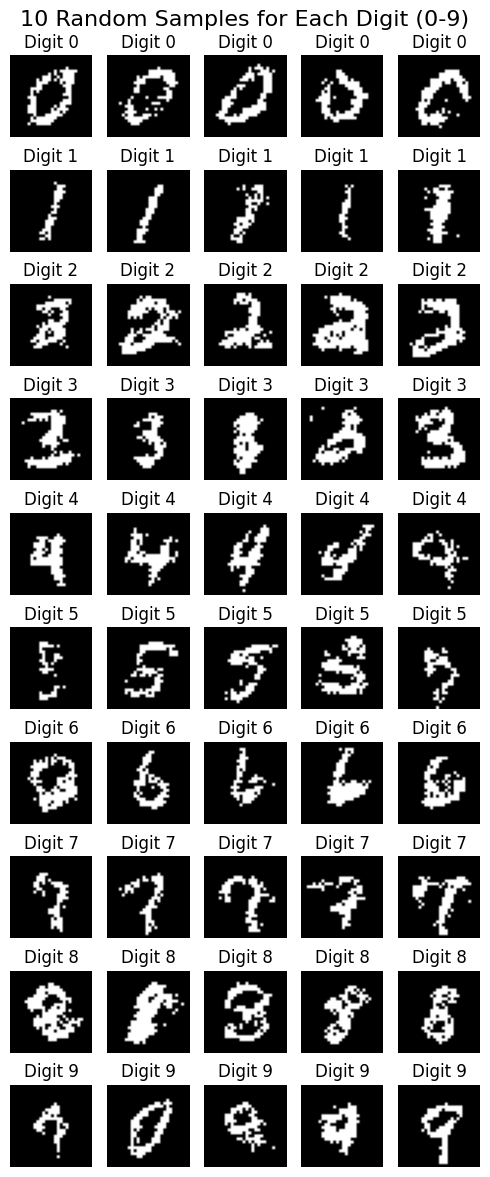

In [6]:
utils.plot_samples_per_digit(5,all_models[0])

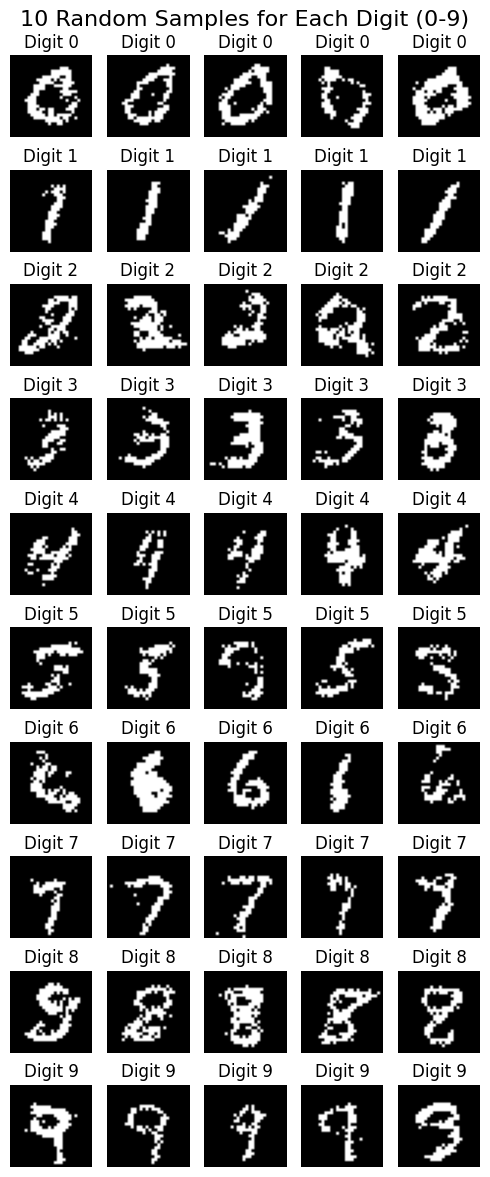

In [7]:
utils.plot_samples_per_digit(5,all_models[-1])